# Aula — Descritiva de cada campo, e o primeiro MLP: o valor dos imóveis da Califórnia

**Análise Preditiva** · material de aula (fora do livro) · dataset: [`ml-zero/dados/california/`](https://github.com/GHDaru/machinelearning/tree/main/ml-zero/dados/california)

20 640 setores censitários (*block groups*) do censo americano de 1990, dez colunas — nove números e uma categoria de texto — e um objetivo: prever o **valor mediano do imóvel** (`median_house_value`) de cada setor.

**Roteiro desta aula:**

0. **Introdução ao dataset** — a unidade (o que é uma linha), o mapa dos dez campos, e as cinco armadilhas que o resto da aula vai confirmar uma a uma.
1. **Conferindo o dado** — tipos, nulidade e categorias, no arquivo de verdade.
2. **Análise descritiva** de cada campo quantitativo — histograma com boxplot, outliers, assimetria, curtose e o cuidado especial de cada um. A mesma régua da Aula 1 (limonada), agora sobre dado real, não sintético.
3. **Diagnóstica rápida** — a correlação de cada campo com o alvo, e o que ela não conta sozinha.
4. **O primeiro MLP: sem tratar os números, mas com *one-hot* na categórica** — os campos numéricos entram **crus**; `ocean_proximity` entra codificada, porque sem isso o `scikit-learn` nem aceita a coluna. Escreva sua previsão antes de rodar.
5. **Com tratamento: os mesmos dados, padronizados** — a mesma rede, para medir se (e quanto) o aprendizado melhora.
6. **Por dentro do MLP** — o que cada hiperparâmetro faz, com equação e visual: arquitetura, ativação, otimizador, regularização e número de épocas.
7. **A sua vez: 40 configurações** — escolha uma arquitetura, ativação, otimizador e número de épocas sobre os dados já tratados, rode e compare.

> Roda no Colab sem instalar nada além do que já vem no ambiente: `pandas`, `numpy`, `scikit-learn`, `matplotlib`. Se o repositório não estiver clonado (o caso do Colab), o CSV é baixado direto do GitHub.
>
> **De onde isto vem:** o mesmo dado é o do [capítulo III.2 — Redes Neurais](https://machinelearning.ghdaru.com.br/iii-2-redes-neurais.html) e do notebook [`rede_california.ipynb`](https://github.com/GHDaru/machinelearning/blob/main/ml-zero/etapa-19/rede_california.ipynb), que **deriva** 8 atributos por domicílio e **padroniza** antes de treinar. Esta aula faz o caminho quase inverso: descritiva primeiro, MLP cru depois, tratamento por último — para você sentir a armadilha da escala antes de ver a solução.

In [1]:
# --- roda igual na sua máquina e no Colab ------------------------------
# No Colab não há repositório: o CSV é baixado direto do GitHub.
import pathlib, urllib.request

RAW = "https://raw.githubusercontent.com/GHDaru/machinelearning/main/"
CSV = "ml-zero/dados/california/housing_bruto.csv"

raiz = pathlib.Path.cwd()
for _ in range(6):
    if (raiz / "ml-zero").is_dir():
        break
    raiz = raiz.parent
else:
    raiz = pathlib.Path.cwd()

caminho = raiz / CSV
if not caminho.exists():
    caminho.parent.mkdir(parents=True, exist_ok=True)
    urllib.request.urlretrieve(RAW + CSV, caminho)
print("dados em:", caminho)

dados em: /home/user/machinelearning/ml-zero/dados/california/housing_bruto.csv


In [2]:
import warnings
import itertools
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore", category=DeprecationWarning)
warnings.filterwarnings("ignore", message=".*vert.*")

# Paleta da aula: um matiz para o dado, laranja só quando há duas séries a
# contrastar, cinza para o que é contexto. Cor segue papel, não enfeite.
AZUL, LARANJA, CINZA = "#4477AA", "#EE7733", "#BBBBBB"
plt.rcParams.update({
    "figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.alpha": 0.25, "axes.axisbelow": True,
    "font.size": 10,
})

def usd(v):
    return f"US$ {v:,.0f}".replace(",", ".")

## 0. Introdução ao dataset

Antes de entrar nos números, uma vista de cima: **o que é uma linha do arquivo**, quais são os dez campos, e onde cada um esconde uma armadilha. Tudo o que vem abaixo é medido no arquivo mais adiante nesta aula — aqui é só o mapa, para servir de referência.

### A unidade: *block group*, não "setor censitário"

Cada linha não é uma casa nem uma pessoa: é um ***block group*** do censo americano de 1990, a menor unidade geográfica para a qual o Census Bureau publica dado amostral.

```
Estado ⊃ Condado ⊃ Census Tract (2.500 a 8.000 moradores) ⊃ Block Group ⊃ Block
                                                             ↑ cada linha do arquivo   (sem renda publicada)
                                                             ideal de 400 domicílios
```

Não confunda com o *census tract* (~3× maior) nem com o "setor censitário" do IBGE. A mediana medida no arquivo (409 domicílios) confirma o nível: em cima do ideal do *block group*, bem abaixo da faixa de um *census tract*.

### Os dez campos

| Campo | Papel | Faixa |
|---|---|---|
| `longitude`, `latitude` | geografia — só fazem sentido **juntas** | −124,35 a −114,31 · 32,54 a 41,95 |
| `housing_median_age` | idade mediana das construções (anos) | 1 a 52 · teto artificial |
| `total_rooms` | total de cômodos do setor **inteiro** | 2 a 39.320 |
| `total_bedrooms` | total de quartos do setor inteiro | 1 a 6.445 · 207 linhas em branco |
| `population` | moradores do setor | 3 a 35.682 |
| `households` | domicílios **ocupados** do setor | 1 a 6.082 |
| `median_income` | renda mediana, em dezenas de milhares de US\$ | 0,50 a 15,00 · censurada nas 2 pontas |
| `ocean_proximity` | categórica, 5 valores | ver armadilha 5 abaixo |
| **`median_house_value`** | **alvo**: valor mediano do imóvel, em US\$ | 14.999 a 500.001 · teto em 500.001 |

### Cinco armadilhas que a seção 2 confirma, uma a uma

1. **Geografia bimodal** — a maioria dos setores cai em só duas faixas estreitas de latitude: Los Angeles e a Baía de São Francisco.
2. **Teto de idade** — 52 anos é onde o censo parou de contar, não a casa mais velha do estado.
3. **Renda censurada** nas duas pontas, com sentinela (`15,0001` e `0,4999`) para distinguir o valor real do valor cortado.
4. **Alvo censurado** em US\$ 500.001 — quase 5% do arquivo, e nenhum modelo pode acertar esses setores.
5. **Categoria rara** — `ISLAND` tem só 5 linhas em 20.640, e pode sumir de uma das três partes do recorte sem avisar.

## 1. Conferindo o dado

Você já viu o mapa. Agora confira se o arquivo bate com ele — a mesma pergunta da Aula 1: **que tipo é cada coluna, e qual o papel dela?**

In [3]:
df = pd.read_csv(caminho)
print(df.shape)
df.head()

(20640, 10)


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  str    
dtypes: float64(9), str(1)
memory usage: 1.6 MB


Dez colunas, 20 640 linhas, batendo com o mapa da introdução. Confira o que falta antes de seguir.

In [5]:
print("valores ausentes:")
print(df.isna().sum()[lambda s: s > 0])
print()
print("ocean_proximity:")
print(df["ocean_proximity"].value_counts())

valores ausentes:
total_bedrooms    207
dtype: int64

ocean_proximity:
ocean_proximity
<1H OCEAN     9136
INLAND        6551
NEAR OCEAN    2658
NEAR BAY      2290
ISLAND           5
Name: count, dtype: int64


**207 linhas em 20 640** (1%) não têm `total_bedrooms`. A [ficha do dado](https://github.com/GHDaru/machinelearning/blob/main/ml-zero/dados/california/README.md) mostra que essas mesmas linhas **têm** valor numa outra cópia do "mesmo" conjunto — não é buraco de coleta, é discrepância entre duas cópias do mesmo arquivo, e nenhuma delas avisa.

Nesta aula a decisão é a mais simples de declarar: **remover as 207 linhas** antes do MLP (seção 4). Isso não é "tratar" a escala nem a forma dos campos — é o mínimo para o `scikit-learn` aceitar a matriz. Tudo o mais chega cru.

## 2. Análise descritiva, campo a campo

O instrumento é o mesmo da Aula 1: **histograma com boxplot em cima**, compartilhando o eixo x. O boxplot resume (mediana, quartis, cercas); o histograma mostra a forma que o resumo esconde. Junto, a assimetria (*skewness*), a curtose (excesso, referência normal = 0) e a contagem de outliers pela regra do IQR (cerca = quartil ± 1,5×IQR).

In [6]:
QUANTS = ["longitude", "latitude", "housing_median_age", "total_rooms",
          "total_bedrooms", "population", "households", "median_income",
          "median_house_value"]

def resumo(s: pd.Series) -> dict:
    s = s.dropna()
    q1, q3 = s.quantile(0.25), s.quantile(0.75)
    iqr = q3 - q1
    lo, hi = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    outliers = s[(s < lo) | (s > hi)]
    return {"n": len(s), "média": s.mean(), "dp": s.std(), "mín": s.min(),
            "Q1": q1, "mediana": s.median(), "Q3": q3, "máx": s.max(),
            "assimetria": s.skew(), "curtose": s.kurt(),
            "cerca inf": lo, "cerca sup": hi, "outliers (IQR)": len(outliers)}

def descritiva(coluna: str, bins=30):
    s = df[coluna]
    fig, (ax_box, ax_hist) = plt.subplots(
        2, 1, sharex=True, figsize=(7, 3.6),
        gridspec_kw={"height_ratios": [1, 4], "hspace": 0.05})
    ax_box.boxplot(s.dropna(), vert=False, widths=0.55, patch_artist=True,
                   boxprops=dict(facecolor=AZUL, alpha=0.45, edgecolor=AZUL),
                   medianprops=dict(color=LARANJA, linewidth=2),
                   flierprops=dict(marker="o", markersize=4,
                                   markerfacecolor=LARANJA, markeredgecolor="none"))
    ax_box.set(yticks=[], title=coluna)
    ax_box.grid(False)
    ax_hist.hist(s.dropna(), bins=bins, color=AZUL, edgecolor="white", linewidth=0.6)
    ax_hist.set_ylabel("setores")
    ax_hist.grid(axis="x", visible=False)
    plt.show()
    linha = pd.Series(resumo(s)).to_frame(coluna).T
    return linha.round(3)

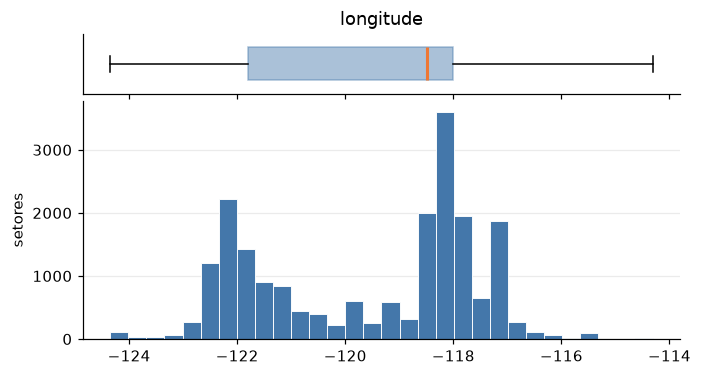

,n,média,dp,mín,Q1,mediana,Q3,máx,assimetria,curtose,cerca inf,cerca sup,outliers (IQR)
longitude,20640.0,-119.57,2.004,-124.35,-121.8,-118.49,-118.01,-114.31,-0.298,-1.33,-127.485,-112.325,0.0


In [7]:
descritiva("longitude")

**Longitude** — leve assimetria negativa, curtose bem mais achatada que a normal, **zero outliers** pela regra do IQR. Mas olhe o histograma, não só os números: há **duas concentrações**, uma perto de −118° e outra perto de −122°. Assimetria e curtose são um resumo de dois números; eles não denunciam uma forma com dois picos — só o histograma mostra isso. Guarde: essas duas concentrações são Los Angeles e a Baía de São Francisco, e só fazem sentido lidas **junto com a latitude**.

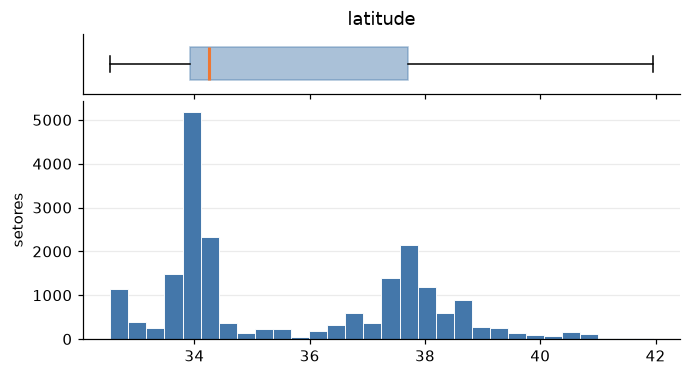

,n,média,dp,mín,Q1,mediana,Q3,máx,assimetria,curtose,cerca inf,cerca sup,outliers (IQR)
latitude,20640.0,35.632,2.136,32.54,33.93,34.26,37.71,41.95,0.466,-1.118,28.26,43.38,0.0


In [8]:
descritiva("latitude")

**Latitude** — a mesma bimodalidade aparece aqui, agora como assimetria positiva mensurável (~0,47): um platô entre 33° e 34° (Los Angeles) e outro entre 37° e 39° (a Baía), com um vale entre os dois. De novo, zero outliers pela regra do IQR — a regra não tem o que fazer com uma forma bimodal, porque ela pressupõe uma única moda.

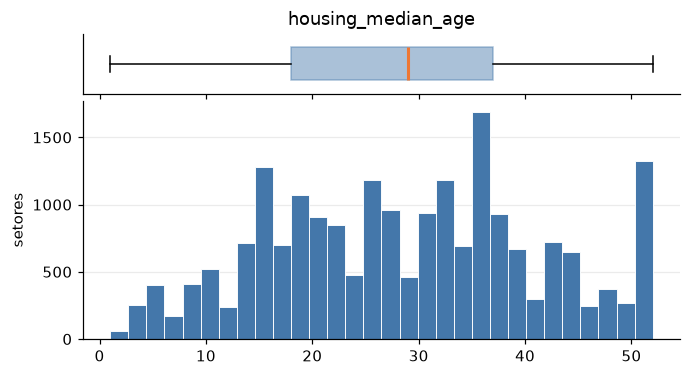

,n,média,dp,mín,Q1,mediana,Q3,máx,assimetria,curtose,cerca inf,cerca sup,outliers (IQR)
housing_median_age,20640.0,28.639,12.586,1.0,18.0,29.0,37.0,52.0,0.06,-0.801,-10.5,65.5,0.0


In [9]:
descritiva("housing_median_age")

**Idade mediana das construções** — quase simétrica (assimetria ≈ 0,06), mediana de 29 anos. Zero outliers pelo IQR, mas há um **cuidado que o IQR não pega**: exatamente em 52 anos (o valor máximo da coluna) empilham-se **1 273 setores — 6,17% do arquivo inteiro**. Não é coincidência estatística, é **top-coding**: o censo registrou "52" para toda construção com 52 anos ou mais. O teto está na régua, não no fenômeno — e ele não aparece como outlier porque é o **valor mais frequente do topo**, não um ponto isolado.

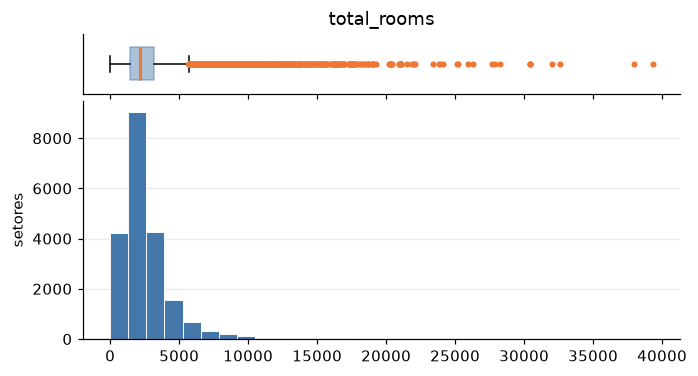

,n,média,dp,mín,Q1,mediana,Q3,máx,assimetria,curtose,cerca inf,cerca sup,outliers (IQR)
total_rooms,20640.0,2635.763,2181.615,2.0,1447.75,2127.0,3148.0,39320.0,4.147,32.631,-1102.625,5698.375,1287.0


In [10]:
descritiva("total_rooms")

**Total de cômodos do setor** — assimetria forte (~4,15) e curtose alta (~32,6): cauda longa e pesada, com **1 287 outliers** pela regra do IQR (mediana 2 127, máximo 39 320). **Tratamento: nenhuma exclusão.** Um setor grande de verdade tem muitos cômodos — isso é o fenômeno, não erro de digitação. É candidato natural a transformação (log), que fica para outra aula.

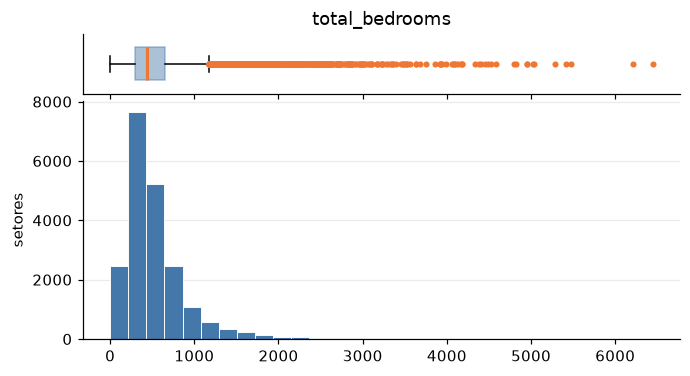

,n,média,dp,mín,Q1,mediana,Q3,máx,assimetria,curtose,cerca inf,cerca sup,outliers (IQR)
total_bedrooms,20433.0,537.871,421.385,1.0,296.0,435.0,647.0,6445.0,3.46,21.986,-230.5,1173.5,1271.0


In [11]:
descritiva("total_bedrooms")

**Total de quartos do setor** — mesma família de forma que `total_rooms` (assimetria ~3,46, curtose ~22,0, **1 271 outliers**), calculada sobre as 20 433 linhas que têm valor. Lembre-se: **não são cômodos de uma casa**, são a soma do setor inteiro — e essa é a razão de o capítulo III.2 dividir por `households` antes de comparar setores entre si.

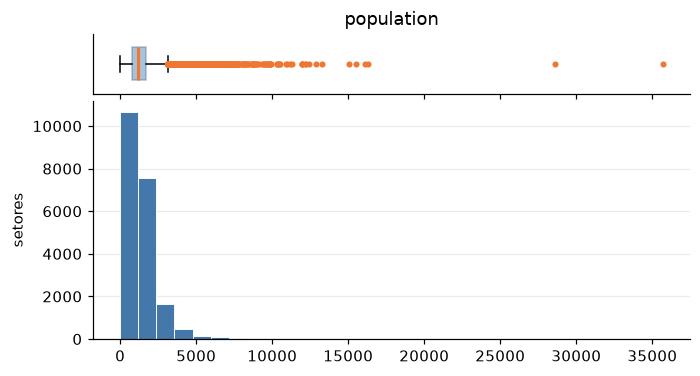

,n,média,dp,mín,Q1,mediana,Q3,máx,assimetria,curtose,cerca inf,cerca sup,outliers (IQR)
population,20640.0,1425.477,1132.462,3.0,787.0,1166.0,1725.0,35682.0,4.936,73.553,-620.0,3132.0,1196.0


In [12]:
descritiva("population")

**População do setor** — a cauda mais extrema do conjunto: assimetria ~4,94, curtose ~73,6, **1 196 outliers**, indo de 3 a 35 682 moradores num único setor. De novo, nenhuma exclusão: são setores densos de verdade, e apagá-los seria apagar exatamente os bairros mais populosos da amostra.

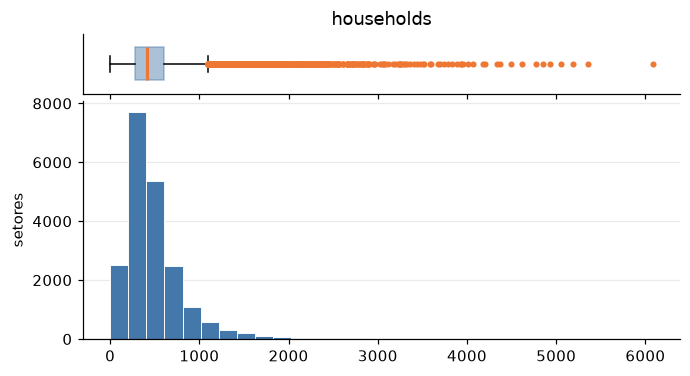

,n,média,dp,mín,Q1,mediana,Q3,máx,assimetria,curtose,cerca inf,cerca sup,outliers (IQR)
households,20640.0,499.54,382.33,1.0,280.0,409.0,605.0,6082.0,3.41,22.058,-207.5,1092.5,1220.0


In [13]:
descritiva("households")

**Domicílios ocupados do setor** — mesmo padrão (assimetria ~3,41, curtose ~22,1, **1 220 outliers**). É o **denominador** dos três atributos que o capítulo III.2 deriva (`AveRooms`, `AveBedrms`, `AveOccup`) — nesta aula ele fica como está, cru, junto com os totais que divide.

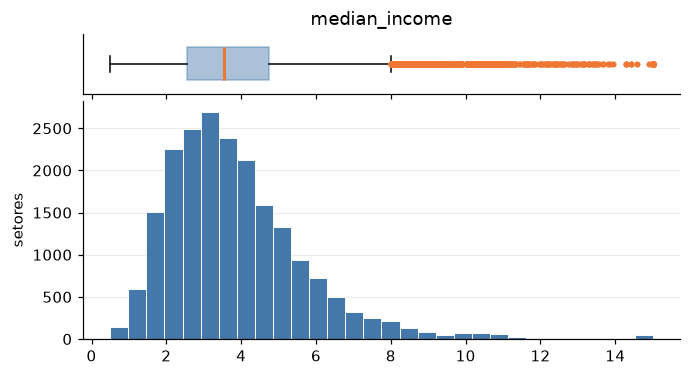

,n,média,dp,mín,Q1,mediana,Q3,máx,assimetria,curtose,cerca inf,cerca sup,outliers (IQR)
median_income,20640.0,3.871,1.9,0.5,2.563,3.535,4.743,15.0,1.647,4.953,-0.706,8.013,681.0


In [14]:
descritiva("median_income")

**Renda mediana do setor** (em dezenas de milhares de dólares) — assimetria à direita (~1,65), curtose alta (~4,95), **681 outliers**. E aqui há **dois tetos, não um**: `15,0001` (49 setores, o piso da censura superior) e `0,4999` (12 setores, o piso da censura inferior). O `,0001` existe para que o valor censurado seja **distinguível** de um valor redondo de verdade — é a convenção do próprio censo. Sozinha, esta coluna já é a mais correlacionada com o alvo, como a seção 3 confirma.

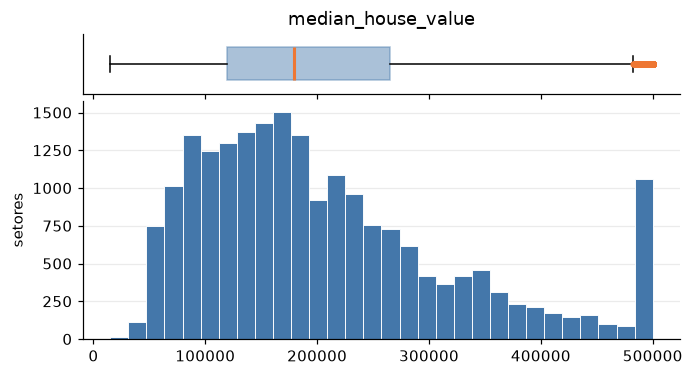

,n,média,dp,mín,Q1,mediana,Q3,máx,assimetria,curtose,cerca inf,cerca sup,outliers (IQR)
median_house_value,20640.0,206855.817,115395.616,14999.0,119600.0,179700.0,264725.0,500001.0,0.978,0.328,-98087.5,482412.5,1071.0


In [15]:
descritiva("median_house_value")

**Valor mediano do imóvel** (o alvo) — assimetria moderada (~0,98), **1 071 outliers** pelo IQR. Boa parte dessa cauda tem uma causa única: o **teto em US\$ 500 001**, com **965 setores exatamente ali (4,68% do arquivo)**. Nenhum modelo vai acertar esses 965 setores — o teto não está no fenômeno, está na régua que o censo usou para publicar o dado. É a mesma lição do `preco` binário da limonada, só que aqui a régua bate no topo em vez de ter dois valores só.

### Síntese da descritiva

In [16]:
pd.DataFrame({c: resumo(df[c]) for c in QUANTS}).T.round(3)

,n,média,dp,mín,Q1,mediana,Q3,máx,assimetria,curtose,cerca inf,cerca sup,outliers (IQR)
longitude,20640.0,-119.570,2.004,-124.35,-121.800,-118.490,-118.010,-114.31,-0.298,-1.330,-127.485,-112.325,0.0
latitude,20640.0,35.632,2.136,32.54,33.930,34.260,37.710,41.95,0.466,-1.118,28.260,43.380,0.0
housing_median_age,20640.0,28.639,12.586,1.00,18.000,29.000,37.000,52.00,0.060,-0.801,-10.500,65.500,0.0
total_rooms,20640.0,2635.763,2181.615,2.00,1447.750,2127.000,3148.000,39320.00,4.147,32.631,-1102.625,5698.375,1287.0
total_bedrooms,20433.0,537.871,421.385,1.00,296.000,435.000,647.000,6445.00,3.460,21.986,-230.500,1173.500,1271.0
population,20640.0,1425.477,1132.462,3.00,787.000,1166.000,1725.000,35682.00,4.936,73.553,-620.000,3132.000,1196.0
households,20640.0,499.540,382.330,1.00,280.000,409.000,605.000,6082.00,3.410,22.058,-207.500,1092.500,1220.0
median_income,20640.0,3.871,1.900,0.50,2.563,3.535,4.743,15.00,1.647,4.953,-0.706,8.013,681.0
median_house_value,20640.0,206855.817,115395.616,14999.00,119600.000,179700.000,264725.000,500001.00,0.978,0.328,-98087.500,482412.500,1071.0


**Cuidados especiais que esta tabela deixa (leve para qualquer dataset):**

1. **Unidade e escala antes de interpretação.** `total_rooms`, `total_bedrooms`, `population` e `households` contam o **setor inteiro**, não uma casa; `median_income` está em dezenas de milhares de dólares.
2. **Outlier não é sinônimo de erro.** As caudas de `total_rooms`, `population` e `households` são setores densos de verdade — excluí-los seria viés, não limpeza.
3. **A regra do IQR pressupõe forma unimodal e sem teto.** Ela fica cega para a bimodalidade de `latitude`/`longitude` e para o platô de `housing_median_age` em 52 — e ainda assim dispara nos 965 setores no teto de `median_house_value`.
4. **Teto e piso (*top*/*bottom-coding*) mudam o significado do extremo.** 52 anos, renda em `15,0001`/`0,4999`, valor em `500 001` não são medidas — são a régua do censo batendo no limite dela.
5. **Assimetria forte é convite a considerar transformação** (candidatos: `total_rooms`, `total_bedrooms`, `population`, `households`, `median_income`) — fica para outra aula.
6. `ocean_proximity` tem uma categoria com **5 linhas em 20 640** (`ISLAND`) — a próxima seção mostra por quê isso importa antes de qualquer codificação.

### A coluna que ficou de fora: `ocean_proximity`

Categórica, cinco valores, distribuição muito desigual. Antes de decidir se ela entra num modelo, meça — não suponha.

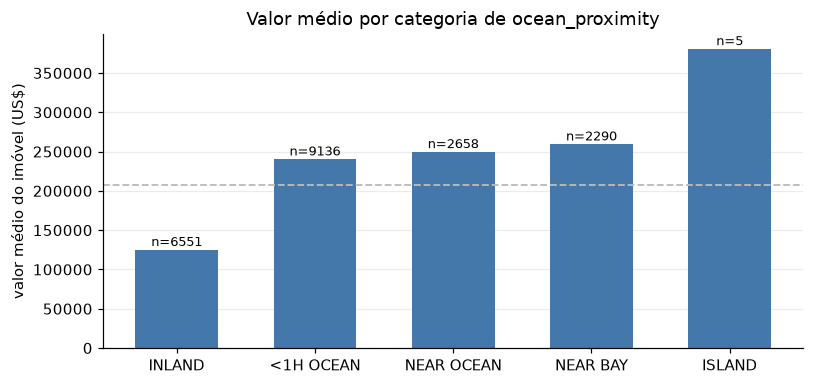

,setores,valor_medio
ocean_proximity,,
INLAND,6551,124805.4
<1H OCEAN,9136,240084.3
NEAR OCEAN,2658,249434.0
NEAR BAY,2290,259212.3
ISLAND,5,380440.0


In [17]:
contagens = df["ocean_proximity"].value_counts()
media_geral = df["median_house_value"].mean()

resumo_categoria = df.groupby("ocean_proximity")["median_house_value"].agg(
    setores="size", valor_medio="mean").sort_values("valor_medio")

fig, ax = plt.subplots(figsize=(7.5, 3.6))
barras = ax.bar(resumo_categoria.index, resumo_categoria["valor_medio"], color=AZUL, width=0.6)
ax.axhline(media_geral, color=CINZA, linestyle="--", linewidth=1.2)
for b, v, n in zip(barras, resumo_categoria["valor_medio"], resumo_categoria["setores"]):
    ax.text(b.get_x() + b.get_width() / 2, v + 5000, f"n={n}", ha="center", fontsize=8.5)
ax.set(ylabel="valor médio do imóvel (US$)", title="Valor médio por categoria de ocean_proximity")
ax.grid(axis="x", visible=False)
plt.tight_layout(); plt.show()

resumo_categoria.round(1)

`INLAND` vale bem menos que o resto, e a coluna claramente carrega sinal. Mas repare em `ISLAND`: **5 linhas em 20 640**. Um recorte treino/teste sorteado ao acaso não tem como garantir presença dessa categoria nas três partes — e um modelo que aprende um peso para uma categoria que **nunca aparece no teste** nunca é avaliado nela.

Mesmo assim, a seção 4 **vai** incluir `ocean_proximity` no MLP, codificada em *one-hot*. É a única forma de uma categórica virar número sem inventar uma ordem que ela não tem — e o preço de incluir uma categoria rara sem cuidado extra é exatamente esse: um parâmetro que talvez nunca seja avaliado no teste. Guarde isso para quando `ISLAND` aparecer de novo.

## 3. Diagnóstica rápida: a correlação com o alvo

O olho viu a forma de cada campo; o número resume como cada um se move com o alvo — e aqui mora uma leitura fácil de fazer errado.

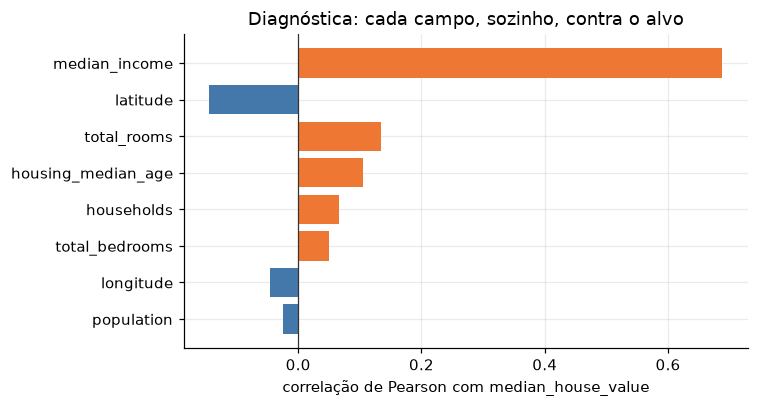

,correlação com o alvo
median_income,0.688
latitude,-0.144
total_rooms,0.134
housing_median_age,0.106
households,0.066
total_bedrooms,0.050
longitude,-0.046
population,-0.025


In [18]:
NUMERICAS = ["longitude", "latitude", "housing_median_age", "total_rooms",
             "total_bedrooms", "population", "households", "median_income"]
ALVO = "median_house_value"

corr = df[NUMERICAS + [ALVO]].corr()[ALVO].drop(ALVO).sort_values(key=abs, ascending=False)

fig, ax = plt.subplots(figsize=(7, 3.8))
cores = [LARANJA if v > 0 else AZUL for v in corr.values]
ax.barh(corr.index[::-1], corr.values[::-1], color=cores[::-1])
ax.axvline(0, color="#333333", linewidth=0.8)
ax.set(xlabel="correlação de Pearson com median_house_value",
       title="Diagnóstica: cada campo, sozinho, contra o alvo")
plt.tight_layout(); plt.show()

corr.round(3).to_frame("correlação com o alvo")

**Leitura ingênua:** `median_income` (+0,69) importa muito, e `population` (−0,02) ou `households` (+0,07) não importam nada. **Essa leitura já está documentada como errada** para este conjunto: a [ficha do dado](https://github.com/GHDaru/machinelearning/blob/main/ml-zero/dados/california/README.md#onde-está-o-resultado-medido-por-ablação) mostra que `latitude` e `longitude`, sozinhas quase sem correlação linear direta, levam uma rede de 0,8982 a **0,7165** de erro (MAE) quando usadas **juntas** — porque a informação está no **par**, e correlação de Pearson mede uma coluna de cada vez.

A diagnóstica de um campo por vez é o primeiro olhar, não o último. É exatamente por isso que a próxima seção treina com **todos** os campos numéricos juntos, mesmo os que aqui parecem fracos.

## 4. O primeiro MLP: sem tratar os números, mas com *one-hot* na categórica

Os oito campos numéricos entram **exatamente como estão no arquivo** — sem padronizar, sem log, sem remover outlier nenhum. A única remoção é técnica: as 207 linhas sem `total_bedrooms`, porque o `scikit-learn` não aceita `NaN`.

`ocean_proximity`, que a seção 2 deixou de fora, entra agora. Mas texto não é número, e o `scikit-learn` não aceita a coluna como está — a saída mínima é o ***one-hot encoding***: uma coluna binária por categoria (`oceano_INLAND`, `oceano_ISLAND`, ...), 1 onde a categoria vale, 0 nas demais. **Isto não é "tratar" o dado** no sentido da escala: é a codificação mínima para uma categórica virar número sem inventar uma ordem que ela não tem. Os totais continuam em suas escalas originais, brutas.

**Escreva sua previsão antes de rodar a próxima célula.** Duas âncoras: prever sempre a mediana erra por **US\$ 90.013** (MAE); uma regressão linear simples erra perto de **US\$ 50 mil**. O MLP cru + *one-hot* vai ficar acima, abaixo, ou entre os dois?

In [19]:
from sklearn.model_selection import train_test_split
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error

completo = df.dropna(subset=["total_bedrooms"]).reset_index(drop=True)
print(f"linhas após remover total_bedrooms ausente: {len(completo)} de {len(df)}")

onehot = pd.get_dummies(completo["ocean_proximity"], prefix="oceano")
print(f"ocean_proximity vira {onehot.shape[1]} colunas: {list(onehot.columns)}")

dados_crus = pd.concat([completo[NUMERICAS], onehot], axis=1)
X = dados_crus.to_numpy(dtype=float)
y = completo[ALVO].to_numpy(dtype=float)

# split fixo (seed 42): simplificado para esta aula — não é o protocolo gravado
# em split.csv que o capítulo III.2 usa, e por isso não é comparável a ele.
Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"treino: {len(ytr)}   teste: {len(yte)}   colunas: {X.shape[1]} (8 numéricas + 5 one-hot)")

linhas após remover total_bedrooms ausente: 20433 de 20640
ocean_proximity vira 5 colunas: ['oceano_<1H OCEAN', 'oceano_INLAND', 'oceano_ISLAND', 'oceano_NEAR BAY', 'oceano_NEAR OCEAN']
treino: 16346   teste: 4087   colunas: 13 (8 numéricas + 5 one-hot)


In [20]:
mediana = DummyRegressor(strategy="median").fit(Xtr, ytr)
linear = LinearRegression().fit(Xtr, ytr)

mae_mediana = mean_absolute_error(yte, mediana.predict(Xte))
mae_linear = mean_absolute_error(yte, linear.predict(Xte))

print(f"linha de base (mediana):  MAE {usd(mae_mediana)}")
print(f"linha de base (linear):   MAE {usd(mae_linear)}")

linha de base (mediana):  MAE US$ 90.013
linha de base (linear):   MAE US$ 50.413


In [21]:
from sklearn.neural_network import MLPRegressor

with warnings.catch_warnings(record=True) as avisos:
    warnings.simplefilter("always")
    mlp_cru = MLPRegressor(hidden_layer_sizes=(64,), activation="relu",
                            solver="adam", random_state=0, max_iter=500)
    mlp_cru.fit(Xtr, ytr)

mae_cru = mean_absolute_error(yte, mlp_cru.predict(Xte))
print(f"MLP cru + one-hot (64, relu, adam):  MAE {usd(mae_cru)}   épocas: {mlp_cru.n_iter_}")
for a in avisos:
    print(f"\naviso emitido: {a.category.__name__}: {a.message}")

MLP cru + one-hot (64, relu, adam):  MAE US$ 61.907   épocas: 500

aviso emitido: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.


### Leia o aviso antes do número

O treino **não travou**: terminou as 500 épocas e devolveu um `ConvergenceWarning` — a mesma classe de sinal fraco do capítulo III.2 ("*a rede crua não treinou mais rápido: ela desistiu antes*"). Aqui a rede nem desiste: ela **converge devagar demais** para o número de épocas dado, porque o terreno tem colinas de tamanhos muito diferentes — `total_rooms` chega a 39 320, as colunas *one-hot* só valem 0 ou 1, e o próprio alvo está em centenas de milhares de dólares.

O resultado é **pior que a regressão linear e melhor que a mediana boba** — um MLP que, à primeira vista, "funciona" (nenhuma exceção, número plausível) mas está deixando dinheiro na mesa: a mesma informação, numa reta, prevê melhor. **Ausência de exceção não é evidência de correção.**

Guarde os três números: mediana, linear, MLP cru + *one-hot*. A seção 5 trata os dados e mede se isso muda.

## 5. Com tratamento: os mesmos dados, agora tratados

"Tratar" aqui quer dizer duas coisas, nas duas pontas da rede:

1. **Padronizar as 8 colunas numéricas** (`StandardScaler`: subtrai a média, divide pelo desvio-padrão, ajustado só no treino) — as 5 colunas *one-hot* ficam como estão, já são 0 ou 1.
2. **Escalar o alvo**, dividindo por 100.000 — a mesma convenção do arquivo derivado (`california.csv`) que o capítulo III.2 usa. Sem isso, a camada de saída precisa de pesos enormes só para alcançar a escala do dólar, antes mesmo de aprender a relação entre atributos e preço.

A arquitetura é **idêntica** à da seção 4 (`(64,)`, `relu`, `adam`) — só os dados mudam. É a mesma lógica das duas linhas de base: isolar uma variável de cada vez.

In [22]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler

pre = ColumnTransformer(
    [("escala", StandardScaler(), list(range(len(NUMERICAS))))],
    remainder="passthrough")  # as 5 colunas one-hot passam direto

Xtr_tratado = pre.fit_transform(Xtr)
Xte_tratado = pre.transform(Xte)
ytr_tratado = ytr / 100_000   # o alvo também é tratado

with warnings.catch_warnings(record=True) as avisos:
    warnings.simplefilter("always")
    mlp_tratado = MLPRegressor(hidden_layer_sizes=(64,), activation="relu",
                                solver="adam", random_state=0, max_iter=500)
    mlp_tratado.fit(Xtr_tratado, ytr_tratado)

mae_tratado = mean_absolute_error(yte, mlp_tratado.predict(Xte_tratado) * 100_000)
print(f"MLP tratado (64, relu, adam):  MAE {usd(mae_tratado)}   épocas: {mlp_tratado.n_iter_}")
print(f"avisos emitidos: {len(avisos)}")

print(f"\ncontra a linha de base (mediana):     {usd(mae_mediana)}")
print(f"contra a linha de base (linear):      {usd(mae_linear)}")
print(f"contra o MLP cru + one-hot (seção 4): {usd(mae_cru)}")
print(f"melhora sobre o MLP cru:              {(mae_cru - mae_tratado) / mae_cru:.1%}")

MLP tratado (64, relu, adam):  MAE US$ 36.997   épocas: 226
avisos emitidos: 0

contra a linha de base (mediana):     US$ 90.013
contra a linha de base (linear):      US$ 50.413
contra o MLP cru + one-hot (seção 4): US$ 61.907
melhora sobre o MLP cru:              40.2%


O tratamento não é cosmético: a rede **converge em menos épocas** (bem menos que as 500 do cru), **sem `ConvergenceWarning`**, e o erro cai o suficiente para **bater a regressão linear** — a mesma informação, na mesma arquitetura, só que agora a otimização consegue enxergar o terreno.

### Qual dos dois tratamentos importa: a entrada, a saída, ou as duas?

Antes de aceitar isso como uma coisa só, separe as duas pontas. Quatro combinações, mesma arquitetura, mesmo `random_state`:

In [23]:
def treinar_mlp(Xtr_, ytr_, Xte_, yte_ref, y_dividido_por=1):
    with warnings.catch_warnings(record=True) as avisos:
        warnings.simplefilter("always")
        m = MLPRegressor(hidden_layer_sizes=(64,), activation="relu",
                          solver="adam", random_state=0, max_iter=500)
        m.fit(Xtr_, ytr_)
    pred = m.predict(Xte_) * y_dividido_por
    return mean_absolute_error(yte_ref, pred), m.n_iter_, len(avisos)

ablacao = pd.DataFrame([
    {"X": "cru",      "y": "cru",      **dict(zip(
        ["MAE", "épocas", "avisos"], treinar_mlp(Xtr, ytr, Xte, yte)))},
    {"X": "escalado", "y": "cru",      **dict(zip(
        ["MAE", "épocas", "avisos"], treinar_mlp(Xtr_tratado, ytr, Xte_tratado, yte)))},
    {"X": "cru",      "y": "escalado", **dict(zip(
        ["MAE", "épocas", "avisos"], treinar_mlp(Xtr, ytr_tratado, Xte, yte, y_dividido_por=100_000)))},
    {"X": "escalado", "y": "escalado", **dict(zip(
        ["MAE", "épocas", "avisos"], treinar_mlp(Xtr_tratado, ytr_tratado, Xte_tratado, yte, y_dividido_por=100_000)))},
])
ablacao["MAE"] = ablacao["MAE"].round(0).astype(int)
ablacao

,X,y,MAE,épocas,avisos
0,cru,cru,61907,500,1
1,escalado,cru,66245,500,1
2,cru,escalado,116197,57,0
3,escalado,escalado,36997,226,0


Nenhum dos dois tratamentos **sozinho** entrega o ganho. Escalar só a entrada mal muda o resultado — dentro do ruído de uma única rodada, chega a empatar com o cru. Escalar só o alvo **piora**, e para cedo: o gradiente ainda sofre com a escala das entradas, e a rede converge rápido para um lugar ruim. É só com **as duas pontas tratadas juntas** que a rede aprende de verdade nesta arquitetura.

Guarde os quatro números: mediana, linear, cru, tratado. As seções 6 e 7 exploram os hiperparâmetros e a arquitetura **sobre os dados tratados**, para não misturar dois problemas na mesma comparação.

## 6. Por dentro do MLP: o que cada hiperparâmetro faz

A seção 7 deixa você escolher entre 40 combinações. Antes de escolher às cegas, cada uma delas explicada: a equação, uma visão e, onde der, um número medido nesta mesma aula.

### A arquitetura: `hidden_layer_sizes`

Um MLP para regressão empilha camadas. Com uma camada escondida, a conta inteira é:

$$h = f(W_1 x + b_1) \qquad \hat{y} = W_2 h + b_2$$

- $x$: o vetor de entrada — 13 números nesta aula (8 numéricos + 5 *one-hot*).
- $W_1, b_1$: pesos e viés da camada escondida — o que `fit` aprende.
- $f$: a ativação (próxima subseção). Sem ela, duas camadas lineares colapsam numa só: $W_2(W_1 x) $ é sempre uma transformação linear, não importa quantas camadas.
- $h$: a camada escondida, com `hidden_layer_sizes[0]` neurônios.
- $W_2, b_2$: pesos e viés da saída. Regressão usa saída **linear**, sem ativação — o modelo precisa prever qualquer número real, não só entre 0 e 1.

`hidden_layer_sizes=(64,)` é uma camada de 64 neurônios; `(64, 32)` são duas camadas em sequência, a informação afunilando de 64 para 32 antes da saída.

parâmetros (W + viés) para 13 entradas nesta aula:
  hidden_layer_sizes=(16,)        -> 241 parâmetros
  hidden_layer_sizes=(64,)        -> 961 parâmetros
  hidden_layer_sizes=(32, 16)     -> 993 parâmetros
  hidden_layer_sizes=(64, 32)     -> 3009 parâmetros


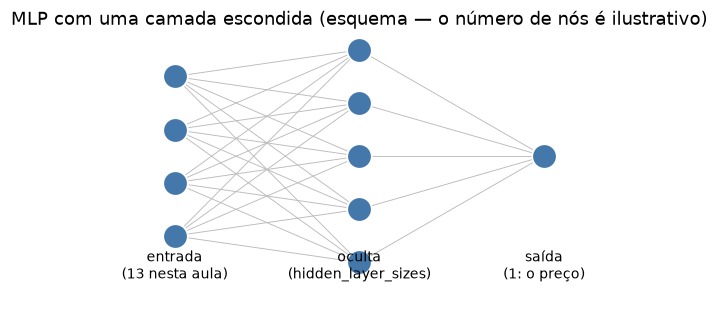

In [24]:
def contar_parametros(n_entrada, ocultas, n_saida=1):
    camadas = [n_entrada] + list(ocultas) + [n_saida]
    return sum(a * b + b for a, b in zip(camadas, camadas[1:]))

print("parâmetros (W + viés) para 13 entradas nesta aula:")
for ocultas in [(16,), (64,), (32, 16), (64, 32)]:
    print(f"  hidden_layer_sizes={ocultas!s:12} -> {contar_parametros(13, ocultas)} parâmetros")

fig, ax = plt.subplots(figsize=(6.5, 3.2))
camadas = [4, 5, 1]  # esquemático — não é a contagem real de entradas desta aula
rotulos = ["entrada\n(13 nesta aula)", "oculta\n(hidden_layer_sizes)", "saída\n(1: o preço)"]
posicoes = [[(x, y) for y in np.linspace(-(n - 1) / 2, (n - 1) / 2, n)]
            for x, n in enumerate(camadas)]
for camada0, camada1 in zip(posicoes, posicoes[1:]):
    for (px0, py0) in camada0:
        for (px1, py1) in camada1:
            ax.plot([px0, px1], [py0, py1], color=CINZA, linewidth=0.6, zorder=1)
for camada in posicoes:
    for (px, py) in camada:
        ax.scatter([px], [py], s=260, color=AZUL, zorder=2, edgecolor="white", linewidth=1.2)
for x, rotulo in enumerate(rotulos):
    ax.text(x, -2.3, rotulo, ha="center", fontsize=9)
ax.set(xlim=(-0.5, 2.5), ylim=(-2.8, 2.3))
ax.axis("off")
ax.set_title("MLP com uma camada escondida (esquema — o número de nós é ilustrativo)")
plt.show()

### A ativação: `activation`

A ativação é o que impede a rede de ser só uma reta disfarçada. As duas desta aula:

$$\text{ReLU}(x) = \max(0, x) \qquad \tanh(x) = \frac{e^x - e^{-x}}{e^x + e^{-x}}$$

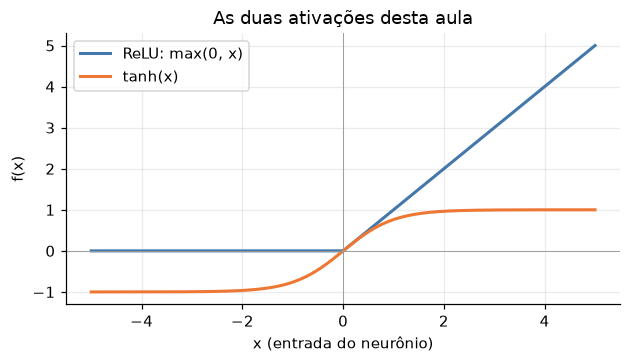

In [25]:
xs = np.linspace(-5, 5, 200)

fig, ax = plt.subplots(figsize=(6.5, 3.2))
ax.plot(xs, np.maximum(0, xs), color=AZUL, linewidth=2, label="ReLU: max(0, x)")
ax.plot(xs, np.tanh(xs), color=LARANJA, linewidth=2, label="tanh(x)")
ax.axhline(0, color="#999999", linewidth=0.6)
ax.axvline(0, color="#999999", linewidth=0.6)
ax.legend()
ax.set(xlabel="x (entrada do neurônio)", ylabel="f(x)", title="As duas ativações desta aula")
plt.show()

**ReLU** é zero para qualquer entrada negativa e a identidade para entrada positiva — barato de calcular, não satura para $x$ grande, mas pode "morrer": um neurônio que só recebe entradas negativas nunca mais tem gradiente. **tanh** satura nas duas pontas (a curva achata perto de −1 e +1) e é centrada em zero — é a ativação que o capítulo III.2 usa, por continuidade com a conta à mão feita lá.

### O otimizador: `solver`

A descida de gradiente comum atualiza cada peso na direção contrária ao gradiente da perda:

$$w \leftarrow w - \eta \nabla L(w)$$

`adam` faz isso **por parâmetro**, guardando uma média móvel do gradiente ($m$) e do gradiente ao quadrado ($v$):

$$m_t = \beta_1 m_{t-1} + (1-\beta_1) g_t \qquad v_t = \beta_2 v_{t-1} + (1-\beta_2) g_t^2 \qquad w \leftarrow w - \eta \, \frac{\hat{m}_t}{\sqrt{\hat{v}_t} + \epsilon}$$

Na prática: cada peso recebe seu próprio passo efetivo, maior onde o gradiente é pequeno e consistente, menor onde é grande ou instável — por isso o `adam` tolera razoavelmente bem colunas em escalas diferentes, mesmo sem padronização (foi o que a seção 4 mostrou).

`lbfgs` é outra família: um método quase-Newton que usa o **histórico** de gradientes para estimar a curvatura da perda (uma aproximação da matriz Hessiana) e dar passos mais informados, sobre o lote inteiro de uma vez — não em mini-lotes. Costuma precisar de menos iterações para o mesmo resultado, mas cada iteração é mais cara, e o `scikit-learn` **não guarda a curva de perda** (`loss_curve_`) para ele como guarda para `adam`.

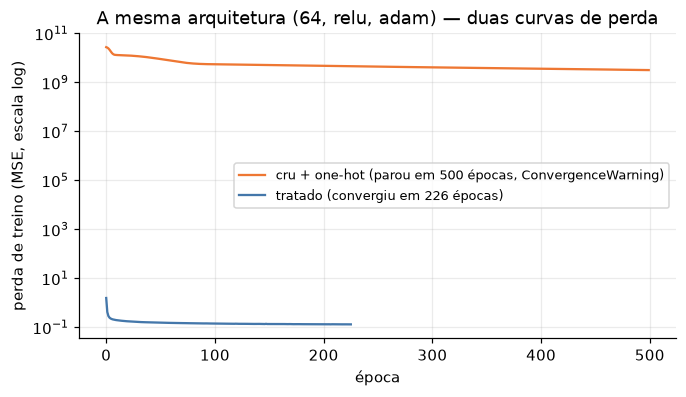

In [26]:
fig, ax = plt.subplots(figsize=(7, 3.6))
ax.plot(mlp_cru.loss_curve_, color=LARANJA,
        label=f"cru + one-hot (parou em {mlp_cru.n_iter_} épocas, ConvergenceWarning)")
ax.plot(mlp_tratado.loss_curve_, color=AZUL,
        label=f"tratado (convergiu em {mlp_tratado.n_iter_} épocas)")
ax.set_yscale("log")
ax.set(xlabel="época", ylabel="perda de treino (MSE, escala log)",
       title="A mesma arquitetura (64, relu, adam) — duas curvas de perda")
ax.legend(fontsize=8.5)
plt.show()

As duas curvas são de modelos que você já treinou, nas seções 4 e 5. A do MLP cru ainda está descendo quando a rede é interrompida — é exatamente isso que o `ConvergenceWarning` está dizendo. A do MLP tratado achata bem antes do limite: mais épocas não ajudariam.

### A regularização: `alpha`

$$\text{perda total} = \text{MSE}(y, \hat{y}) + \alpha \sum_i w_i^2$$

Pesos grandes custam caro à perda total, então `alpha` maior empurra a rede para pesos menores e funções mais suaves — menos capacidade de decorar o treino, mais risco de subajuste se exagerar. Veja o efeito, medido:

In [27]:
for alpha_teste in [0.0001, 0.01, 1, 10]:
    m = MLPRegressor(hidden_layer_sizes=(64,), activation="relu", solver="adam",
                      alpha=alpha_teste, random_state=0, max_iter=300)
    m.fit(Xtr_tratado, ytr_tratado)
    mae = mean_absolute_error(yte, m.predict(Xte_tratado) * 100_000)
    print(f"alpha={alpha_teste:<8} MAE {usd(mae)}")

alpha=0.0001   MAE US$ 36.997


alpha=0.01     MAE US$ 37.057


alpha=1        MAE US$ 41.490


alpha=10       MAE US$ 49.048


Entre `0.0001` e `0.01` (os dois primeiros valores) o efeito é minúsculo; a partir de `1` a regularização já pesa mais que a arquitetura, e em `10` o MLP perde boa parte do ganho sobre a regressão linear. Por isso a tabela da seção 7 fixa `alpha=0.0001` (o padrão do `scikit-learn`) para todo mundo, e abre espaço para o hiperparâmetro que falta.

### As épocas: `max_iter`

Para `adam` (e `sgd`), uma época é uma passada inteira pelo conjunto de treino, e `max_iter` é o teto de épocas — o treino também pode parar antes, se a perda deixar de melhorar por `n_iter_no_change` épocas seguidas (o critério de parada antecipada). Para `lbfgs`, `max_iter` conta iterações do otimizador, não épocas — outra unidade, o que torna comparar "número de iterações" entre os dois solvers uma comparação injusta de cara.

O `ConvergenceWarning` que já apareceu duas vezes nesta aula significa exatamente isto: **o treino foi interrompido pelo teto, não porque aprendeu tudo o que podia**. Olhe de novo o gráfico de perda acima — é a explicação visual do aviso.

## 7. A sua vez: 40 configurações

Com os dados já tratados (seção 5), esta aula explora o **outro eixo**: o que muda quando se mexe na arquitetura e nos hiperparâmetros do MLP, mantendo o tratamento fixo — padronizado na entrada, escalado na saída.

Quatro hiperparâmetros, combinados por completo (5 × 2 × 2 × 2 = **40 formatos**). `alpha` fica fixo em `0.0001` (seção 6) para abrir espaço para `max_iter`, que a seção 6 pediu para testar:

| Hiperparâmetro | Valores | O que ele controla |
|---|---|---|
| `hidden_layer_sizes` | `(16,)` `(32,)` `(64,)` `(32,16)` `(64,32)` | largura e profundidade da rede |
| `activation` | `relu`, `tanh` | a curva de cada neurônio |
| `solver` | `adam`, `lbfgs` | o otimizador — gradiente estocástico × quase-Newton em lote |
| `max_iter` | `50`, `400` | o teto de épocas/iterações antes de parar |

A tabela abaixo é **gerada por código**, não digitada — é o mesmo espírito da ficha do dado: número publicado tem que vir de algo que o regenera.

In [28]:
ARQUITETURAS = [(16,), (32,), (64,), (32, 16), (64, 32)]
ATIVACOES = ["relu", "tanh"]
SOLVERS = ["adam", "lbfgs"]
MAX_ITERS = [50, 400]   # baixo: quase garante ConvergenceWarning · alto: costuma bastar

combinacoes = list(itertools.product(ARQUITETURAS, ATIVACOES, SOLVERS, MAX_ITERS))
assert len(combinacoes) == 40

tabela = pd.DataFrame(combinacoes, columns=["ocultas", "ativacao", "solver", "max_iter"])
tabela.insert(0, "formato", [f"F{i+1:02d}" for i in range(len(tabela))])
tabela = tabela.set_index("formato")
tabela

,ocultas,ativacao,solver,max_iter
formato,,,,
F01,"(16,)",relu,adam,50
F02,"(16,)",relu,adam,400
F03,"(16,)",relu,lbfgs,50
F04,"(16,)",relu,lbfgs,400
F05,"(16,)",tanh,adam,50
F06,"(16,)",tanh,adam,400
F07,"(16,)",tanh,lbfgs,50
F08,"(16,)",tanh,lbfgs,400
F09,"(32,)",relu,adam,50


**Escolha um `FORMATO`** (converse com o colega ao lado para não escolherem o mesmo), troque a primeira linha da célula abaixo e rode. Guarde o MAE que aparecer — é o número que você leva para a aula.

In [29]:
FORMATO = "F01"        # <-- ESCOLHA AQUI, entre F01 e F40
MINHA_PREVISAO = 0.0    # <-- escreva, em dólares, antes de rodar

linha = tabela.loc[FORMATO]
print(f"configuração {FORMATO}:  ocultas={linha.ocultas}  ativação={linha.ativacao}  "
      f"solver={linha.solver}  max_iter={linha.max_iter}  (alpha fixo em 0.0001)")

with warnings.catch_warnings(record=True) as avisos:
    warnings.simplefilter("always")
    meu_mlp = MLPRegressor(hidden_layer_sizes=linha.ocultas, activation=linha.ativacao,
                            solver=linha.solver, max_iter=linha.max_iter,
                            random_state=0)
    meu_mlp.fit(Xtr_tratado, ytr_tratado)   # dados tratados: seção 5, não a seção 4

meu_mae = mean_absolute_error(yte, meu_mlp.predict(Xte_tratado) * 100_000)
epocas = getattr(meu_mlp, "n_iter_", "n/d (lbfgs não conta por época)")

print(f"\nMAE de {FORMATO}:        {usd(meu_mae)}   (épocas/iterações: {epocas})")
print(f"sua previsão era:     {usd(MINHA_PREVISAO)}")
print(f"\ncontra a linha de base (mediana):              {usd(mae_mediana)}")
print(f"contra a linha de base (linear):               {usd(mae_linear)}")
print(f"contra o MLP cru + one-hot (seção 4):          {usd(mae_cru)}")
print(f"contra o MLP tratado (64, relu, adam) (seção 5): {usd(mae_tratado)}")

if avisos:
    print(f"\navisos emitidos: {len(avisos)} — leia antes de comemorar ou desistir")
    for a in avisos[:3]:
        print(f"  {a.category.__name__}: {str(a.message)[:150]}")
else:
    print("\nnenhum aviso emitido nesta configuração.")

configuração F01:  ocultas=(16,)  ativação=relu  solver=adam  max_iter=50  (alpha fixo em 0.0001)



MAE de F01:        US$ 42.724   (épocas/iterações: 50)
sua previsão era:     US$ 0

contra a linha de base (mediana):              US$ 90.013
contra a linha de base (linear):               US$ 50.413
contra o MLP cru + one-hot (seção 4):          US$ 61.907
contra o MLP tratado (64, relu, adam) (seção 5): US$ 36.997

avisos emitidos: 1 — leia antes de comemorar ou desistir


### Como analisar o seu resultado

Uma rodada só é **amostra de tamanho 1** — a Aula do capítulo III.2 usa cinco sementes e reporta a mediana com a amplitude, exatamente porque um único número pode enganar. Antes de concluir "meu formato é melhor", pergunte:

1. **Bati o MLP tratado da seção 5?** Se não, a arquitetura ou o otimizador diferentes não estão comprando nada sobre a configuração mais simples — o que mudou pode ser só ruído.
2. **Seu `FORMATO` caiu em `max_iter=50`?** Se sim, e veio `ConvergenceWarning`, isso é esperado — é o ponto da seção 6, não uma falha sua. Compare com o mesmo modelo em `max_iter=400` (troque só esse campo na tabela) antes de julgar a arquitetura.
3. **Rode de novo trocando só `random_state=0` por outro valor.** Se o MAE mudar mais do que a diferença entre o seu formato e o de um colega, a diferença observada é ruído, não mérito de configuração — a mesma lição da "amplitude" das duas aulas anteriores.

**Leve para a aula:** o `FORMATO` escolhido, o MAE obtido, se houve aviso, e se a diferença para o MLP tratado (seção 5) sobreviveria a uma segunda semente.

## 8. Síntese da aula

1. **Descritiva** é forma + resumo, campo a campo — e aqui ela pegou uma bimodalidade (`latitude`/`longitude`), dois *top-codings* (`housing_median_age`, `median_income`) e um teto que vira "outlier" em massa (`median_house_value`), sem que a regra do IQR entendesse nenhum dos três pelo que realmente são.
2. **Diagnóstica de um campo por vez engana.** `latitude`/`longitude` parecem fracas sozinhas e, juntas, valem mais do que qualquer outra dupla do conjunto.
3. **Codificar uma categórica não é "tratar a escala".** *One-hot* foi necessário para `ocean_proximity` virar número; mesmo assim, com os oito numéricos ainda crus, a rede converge mal e **perde** para uma regressão linear simples.
4. **O tratamento tem duas pontas, e as duas importam juntas.** Escalar só a entrada, ou só o alvo, não resolve — às vezes piora. Padronizar a entrada **e** escalar o alvo, na mesma arquitetura, cortou o erro em 40% e passou a bater a regressão linear.
5. **Cada hiperparâmetro tem um mecanismo, não é só um nome no `MLPRegressor`.** Arquitetura muda a equação em si; ativação decide se a rede pode curvar; o otimizador decide como o peso se move; `alpha` penaliza peso grande; `max_iter` é só o teto — e um teto baixo produz `ConvergenceWarning` mesmo numa arquitetura boa.
6. **A exploração de hiperparâmetros (seção 7) só vale a pena depois do tratamento.** Comparar arquiteturas sobre dado cru mistura dois problemas na mesma tabela — e um `FORMATO` com `max_iter=50` não perdeu por ser ruim, perdeu por não ter tido tempo de treinar.

**Para ver a solução de referência** — os 8 atributos derivados por domicílio, o protocolo gravado em `split.csv`, e cinco sementes por configuração — veja [`rede_california.ipynb`](https://github.com/GHDaru/machinelearning/blob/main/ml-zero/etapa-19/rede_california.ipynb) e o [capítulo III.2](https://machinelearning.ghdaru.com.br/iii-2-redes-neurais.html).